# 📡 TelecomX – Análisis de Evasión de Clientes (Churn)

> **Objetivo:** Identificar los factores que impulsan la cancelación de clientes en TelecomX,
> generando insights accionables para modelos predictivos y estrategias de retención.

---
**Dataset:** `TelecomX_Data.json` — 7,267 registros  
**Pipeline:** Extracción → Transformación → Carga → EDA → Informe


# 📌 1. Extracción

Cargamos el JSON directamente con Python (simulando llamada a API) y lo aplanamos con `json_normalize`.

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# ── Carga desde archivo JSON (simula llamada a API) ──────────────────
JSON_PATH = 'TelecomX_Data.json'

with open(JSON_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

print(f'Registros cargados: {len(raw_data):,}')
print(f'Claves del primer registro: {list(raw_data[0].keys())}')


Registros cargados: 7,267
Claves del primer registro: ['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']


In [ ]:
# ── Aplanar JSON anidado con json_normalize ──────────────────────────
df_raw = pd.json_normalize(raw_data)
print('Shape inicial:', df_raw.shape)
df_raw.head(3)


Shape inicial: (7267, 20)


# 🔧 2. Transformación

## 2.1 Estandarización de columnas

In [ ]:
# Estandarizar nombres de columnas (lower + snake_case)
df_raw.columns = (
    df_raw.columns
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('.', '_', regex=False)
)
print('Columnas estandarizadas:')
print(list(df_raw.columns))


Columnas estandarizadas:
['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen', 'customer_partner',
 'customer_dependents', 'customer_tenure', 'phone_phoneservice', 'phone_multiplelines',
 'internet_internetservice', 'internet_onlinesecurity', 'internet_onlinebackup',
 'internet_deviceprotection', 'internet_techsupport', 'internet_streamingtv',
 'internet_streamingmovies', 'account_contract', 'account_paperlessbilling',
 'account_paymentmethod', 'account_charges_monthly', 'account_charges_total']


## 2.2 Exploración de tipos y estructura

In [ ]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
dtypes: float64(1), int64(1), object(18)


In [ ]:
print(df_raw.dtypes)


## 2.3 Verificación de calidad

In [ ]:
nulos = df_raw.isnull().sum()
print('Valores nulos por columna:')
print(nulos[nulos > 0])
print(f'\nFilas duplicadas: {df_raw.duplicated().sum()}')


Valores nulos por columna:
account_charges_total    11
dtype: int64

Filas duplicadas: 0


In [ ]:
# Valores únicos en columnas categóricas clave
for col in ['churn', 'account_contract', 'internet_internetservice', 'account_paymentmethod']:
    if col in df_raw.columns:
        print(f'{col}: {df_raw[col].unique()}')


churn: ['No' 'Yes']
account_contract: ['One year' 'Month-to-month' 'Two year']
internet_internetservice: ['DSL' 'Fiber optic' 'No']
account_paymentmethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)' 'Bank transfer (automatic)']


## 2.4 Correcciones y limpieza

In [ ]:
df = df_raw.copy()

rename_map = {
    'customerid':'customer_id', 'customer_seniorcitizen':'senior_citizen',
    'customer_gender':'gender', 'customer_partner':'partner',
    'customer_dependents':'dependents', 'customer_tenure':'tenure',
    'phone_phoneservice':'phone_service', 'phone_multiplelines':'multiple_lines',
    'internet_internetservice':'internet_service', 'internet_onlinesecurity':'online_security',
    'internet_onlinebackup':'online_backup', 'internet_deviceprotection':'device_protection',
    'internet_techsupport':'tech_support', 'internet_streamingtv':'streaming_tv',
    'internet_streamingmovies':'streaming_movies', 'account_contract':'contract',
    'account_paperlessbilling':'paperless_billing', 'account_paymentmethod':'payment_method',
    'account_charges_monthly':'monthly_charges', 'account_charges_total':'total_charges',
}
df.rename(columns=rename_map, inplace=True)

# Convertir total_charges a numérico e imputar nulos
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
mask = df['total_charges'].isna()
df.loc[mask, 'total_charges'] = df.loc[mask, 'monthly_charges'] * df.loc[mask, 'tenure']
print(f'Nulos en total_charges tras imputación: {df["total_charges"].isna().sum()}')

# Estandarizar strings
str_cols = df.select_dtypes('object').columns.drop('customer_id', errors='ignore')
df[str_cols] = df[str_cols].apply(lambda s: s.str.strip().str.lower())

# Variable binaria y etiqueta senior
df['churn_flag'] = df['churn'].map({'yes': 1, 'no': 0})
df['senior_citizen_label'] = df['senior_citizen'].map({1: 'yes', 0: 'no'})

print('Shape final:', df.shape)
df.head(3)


Nulos en total_charges tras imputación: 0
Shape final: (7267, 23)


# 📊 3. Análisis Exploratorio de Datos (EDA)

## 3.1 Estadísticas descriptivas

In [ ]:
df.describe(include='all').T


## 3.2 Distribución de Churn

Tasa de Churn global: 25.72%


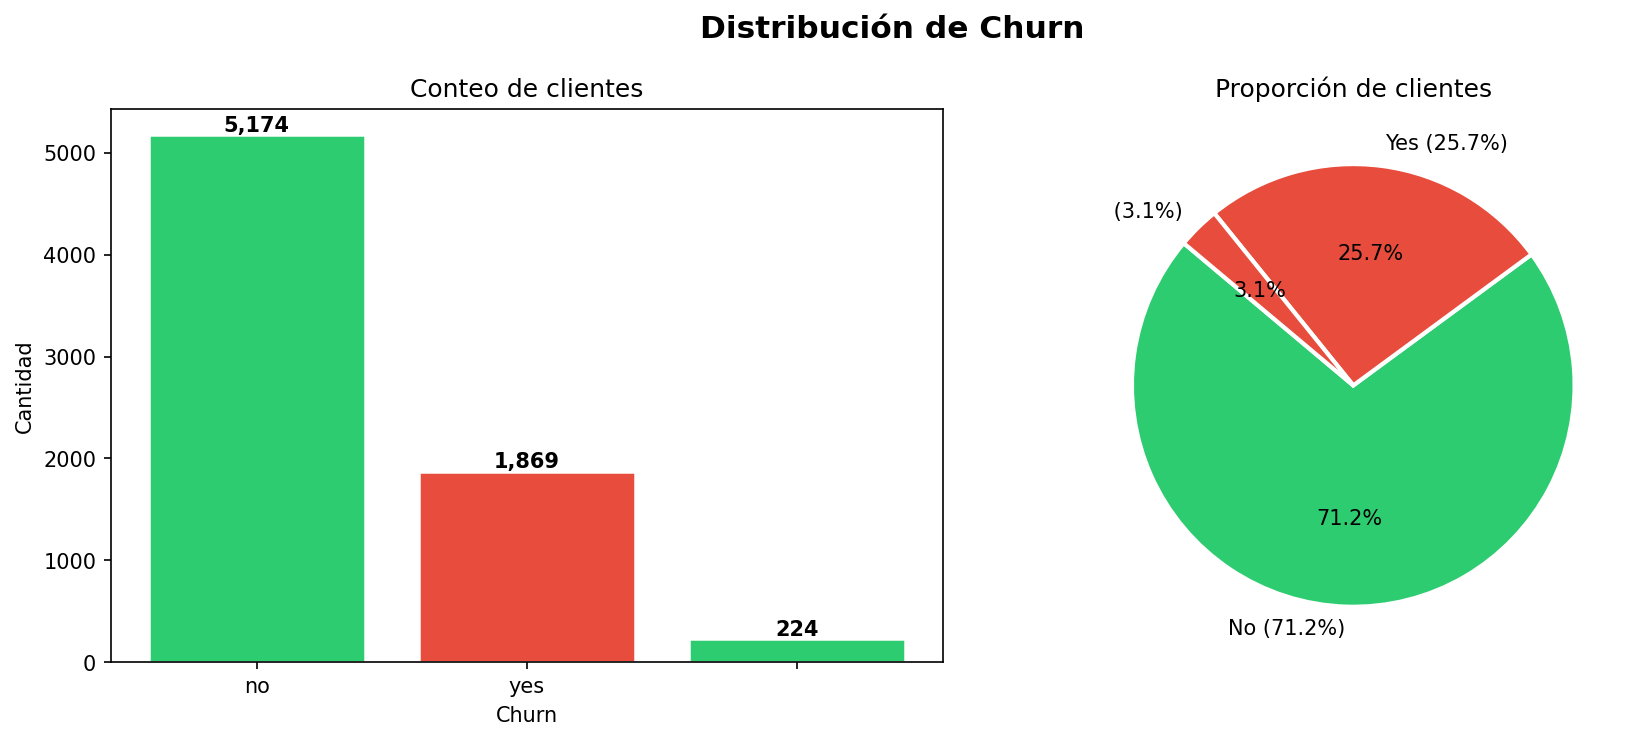

In [ ]:
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribución de Churn', fontsize=15, fontweight='bold')
colors = ['#2ecc71', '#e74c3c']

bars = axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Conteo de clientes')
axes[0].set_xlabel('Churn'); axes[0].set_ylabel('Cantidad')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+40,
                 f'{val:,}', ha='center', fontweight='bold')

pie_labels = [f'{k.title()} ({v:.1f}%)' for k, v in churn_pct.items()]
pie_colors = ['#2ecc71' if k == 'no' else '#e74c3c' for k in churn_pct.index]
axes[1].pie(list(churn_pct.values), labels=pie_labels, colors=pie_colors,
            autopct='%1.1f%%', startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporción de clientes')

plt.tight_layout(); plt.show()
print(f'Tasa de Churn global: {churn_pct["yes"]:.2f}%')


## 3.3 Tasa de Churn por variables categóricas

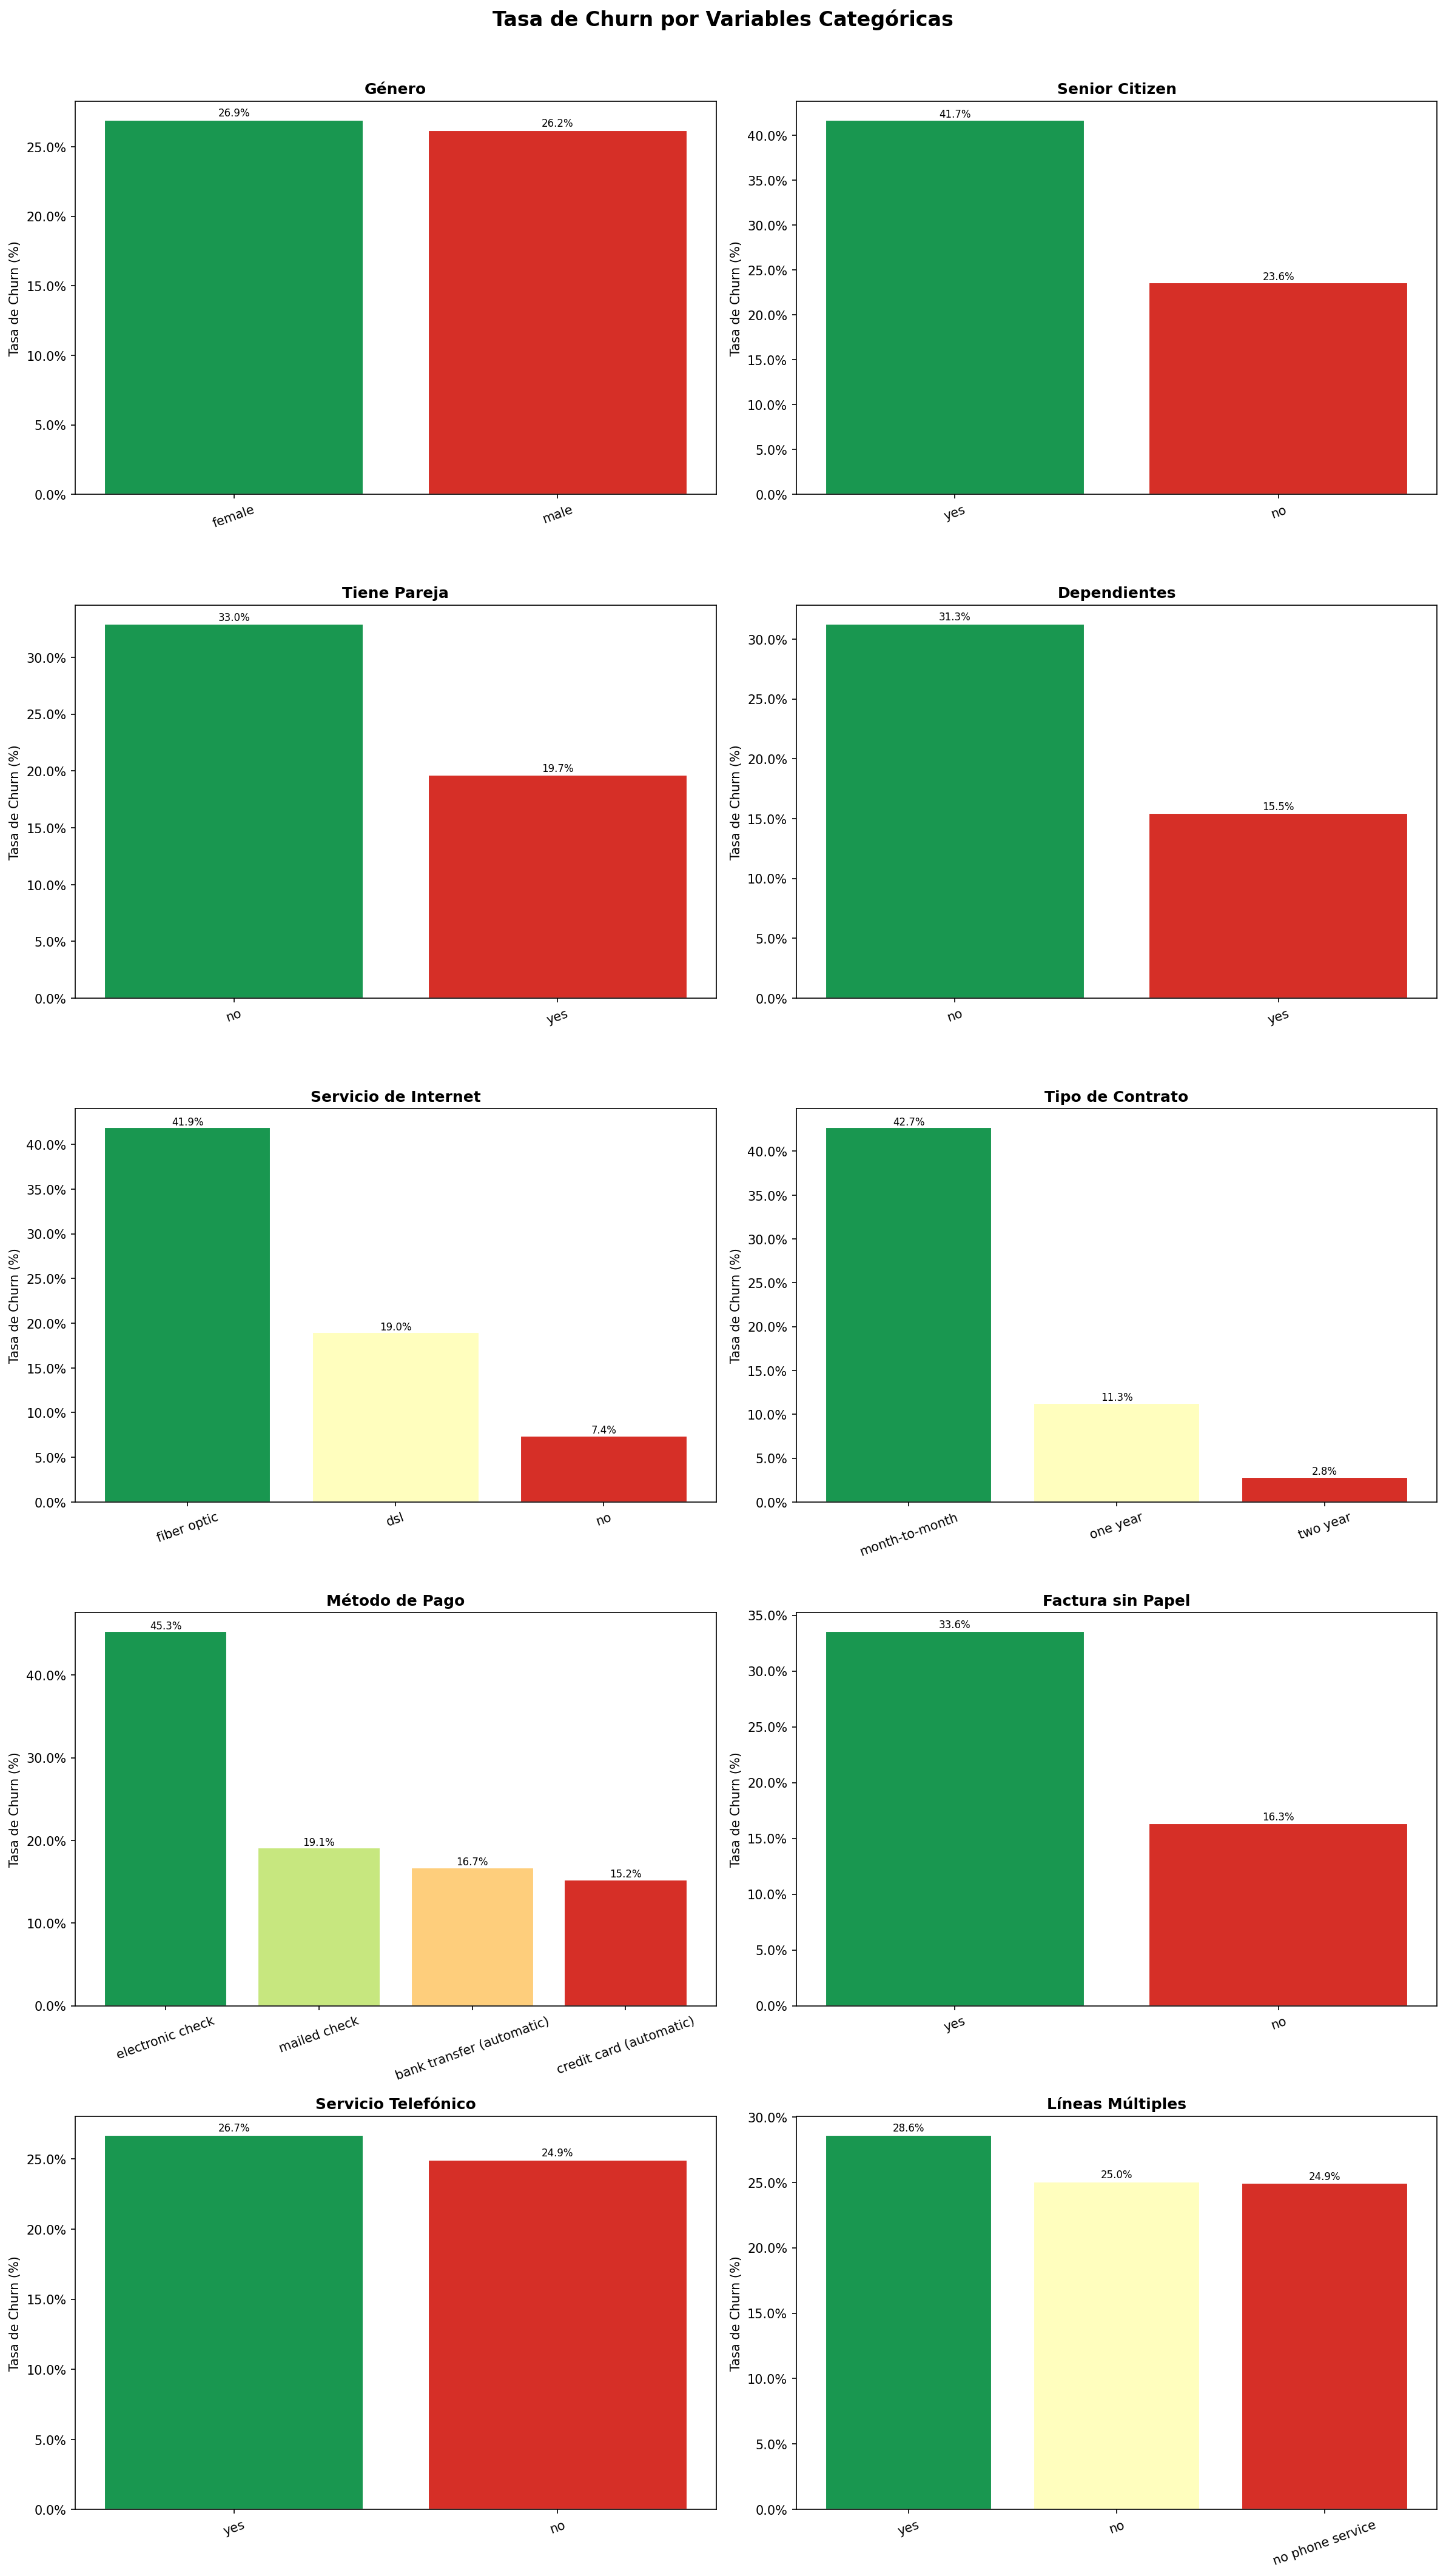

In [ ]:
cat_features = [
    ('gender', 'Género'), ('senior_citizen_label', 'Senior Citizen'),
    ('partner', 'Tiene Pareja'), ('dependents', 'Dependientes'),
    ('internet_service', 'Servicio de Internet'), ('contract', 'Tipo de Contrato'),
    ('payment_method', 'Método de Pago'), ('paperless_billing', 'Factura sin Papel'),
    ('phone_service', 'Servicio Telefónico'), ('multiple_lines', 'Líneas Múltiples'),
]
fig, axes = plt.subplots(5, 2, figsize=(16, 28))
fig.suptitle('Tasa de Churn por Variables Categóricas', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()
for idx, (col, label) in enumerate(cat_features):
    if col not in df.columns: continue
    tasa = df.groupby(col)['churn_flag'].mean().sort_values(ascending=False) * 100
    bars = axes[idx].bar(tasa.index, tasa.values,
                         color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(tasa))),
                         edgecolor='white')
    axes[idx].set_title(label, fontweight='bold'); axes[idx].set_ylabel('Tasa de Churn (%)')
    axes[idx].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[idx].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, tasa.values):
        axes[idx].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                       f'{val:.1f}%', ha='center', fontsize=8)
plt.tight_layout(); plt.show()


## 3.4 Distribución de variables numéricas por Churn

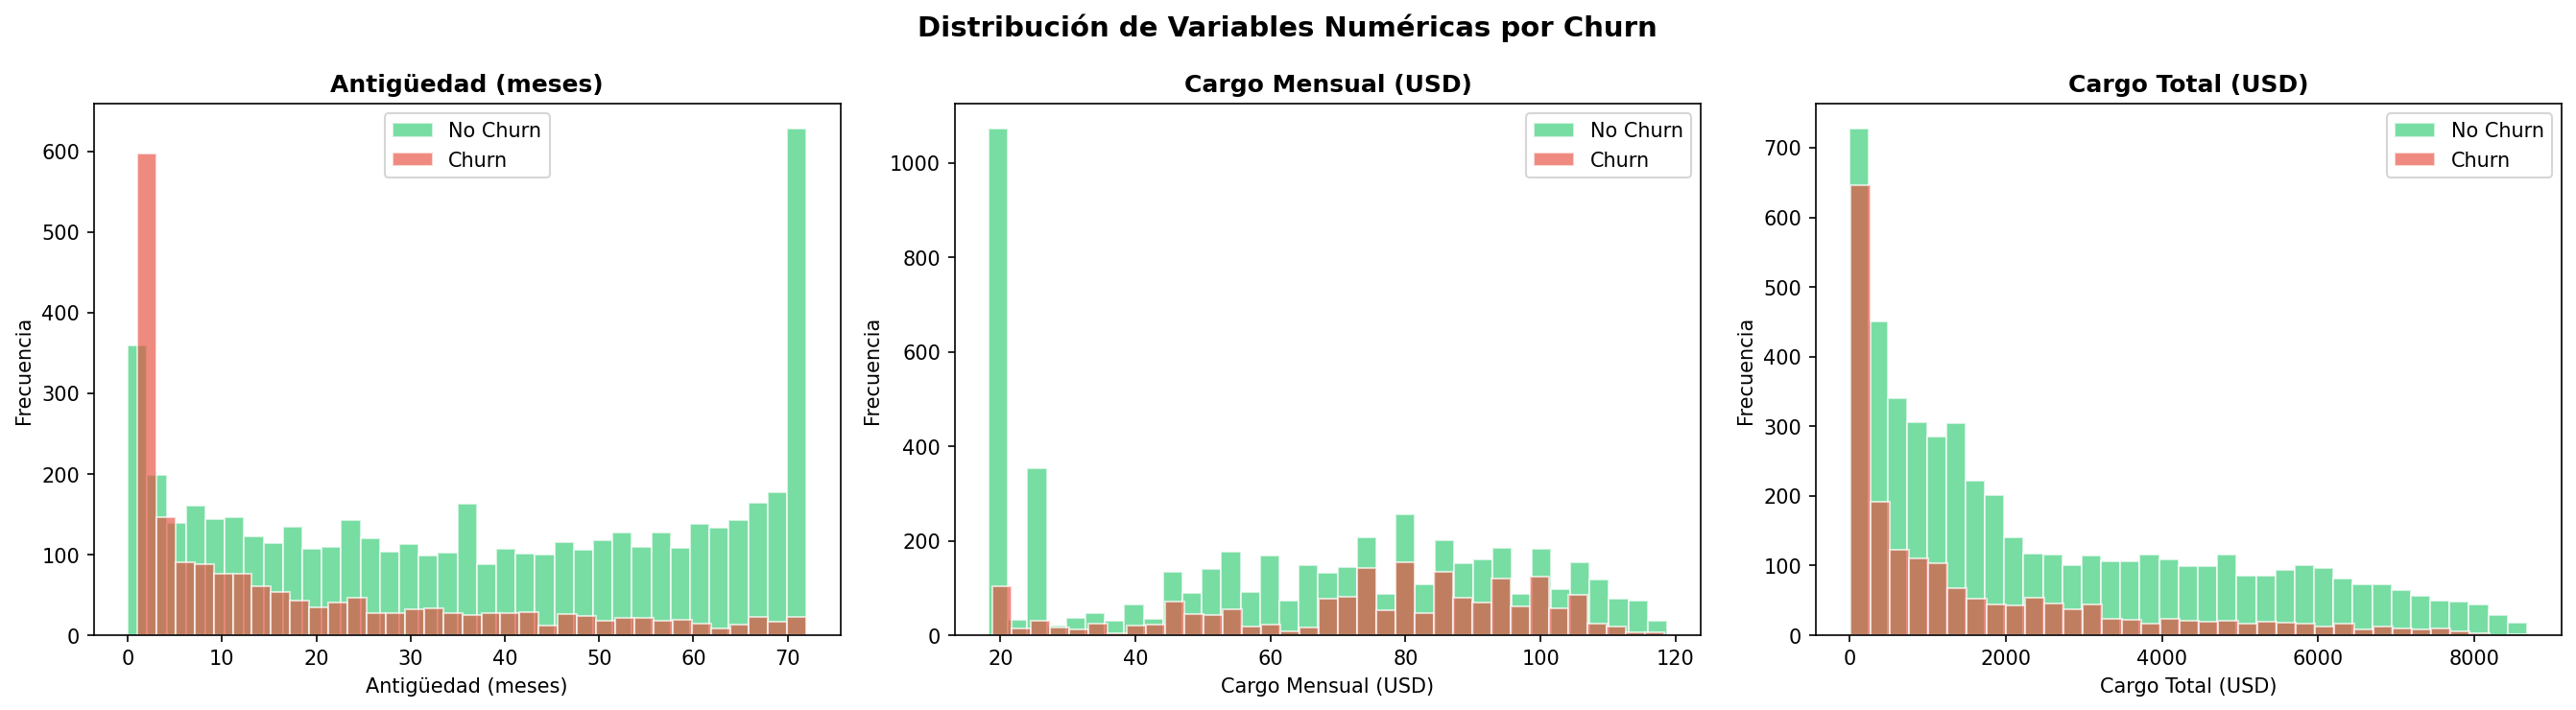

In [ ]:
num_features = ['tenure', 'monthly_charges', 'total_charges']
labels_num   = ['Antigüedad (meses)', 'Cargo Mensual (USD)', 'Cargo Total (USD)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Variables Numéricas por Churn', fontsize=14, fontweight='bold')
for ax, feat, lab in zip(axes, num_features, labels_num):
    for churn_val, color, lbl in [('no', '#2ecc71', 'No Churn'), ('yes', '#e74c3c', 'Churn')]:
        ax.hist(df[df['churn'] == churn_val][feat].dropna(),
                bins=35, alpha=0.65, color=color, label=lbl, edgecolor='white')
    ax.set_title(lab, fontweight='bold'); ax.set_xlabel(lab); ax.set_ylabel('Frecuencia'); ax.legend()
plt.tight_layout(); plt.show()


## 3.5 Regresión lineal: Antigüedad vs. Cargo Total (NumPy)

Pendiente Churn:    92.36 USD/mes
Pendiente No-Churn: 76.69 USD/mes


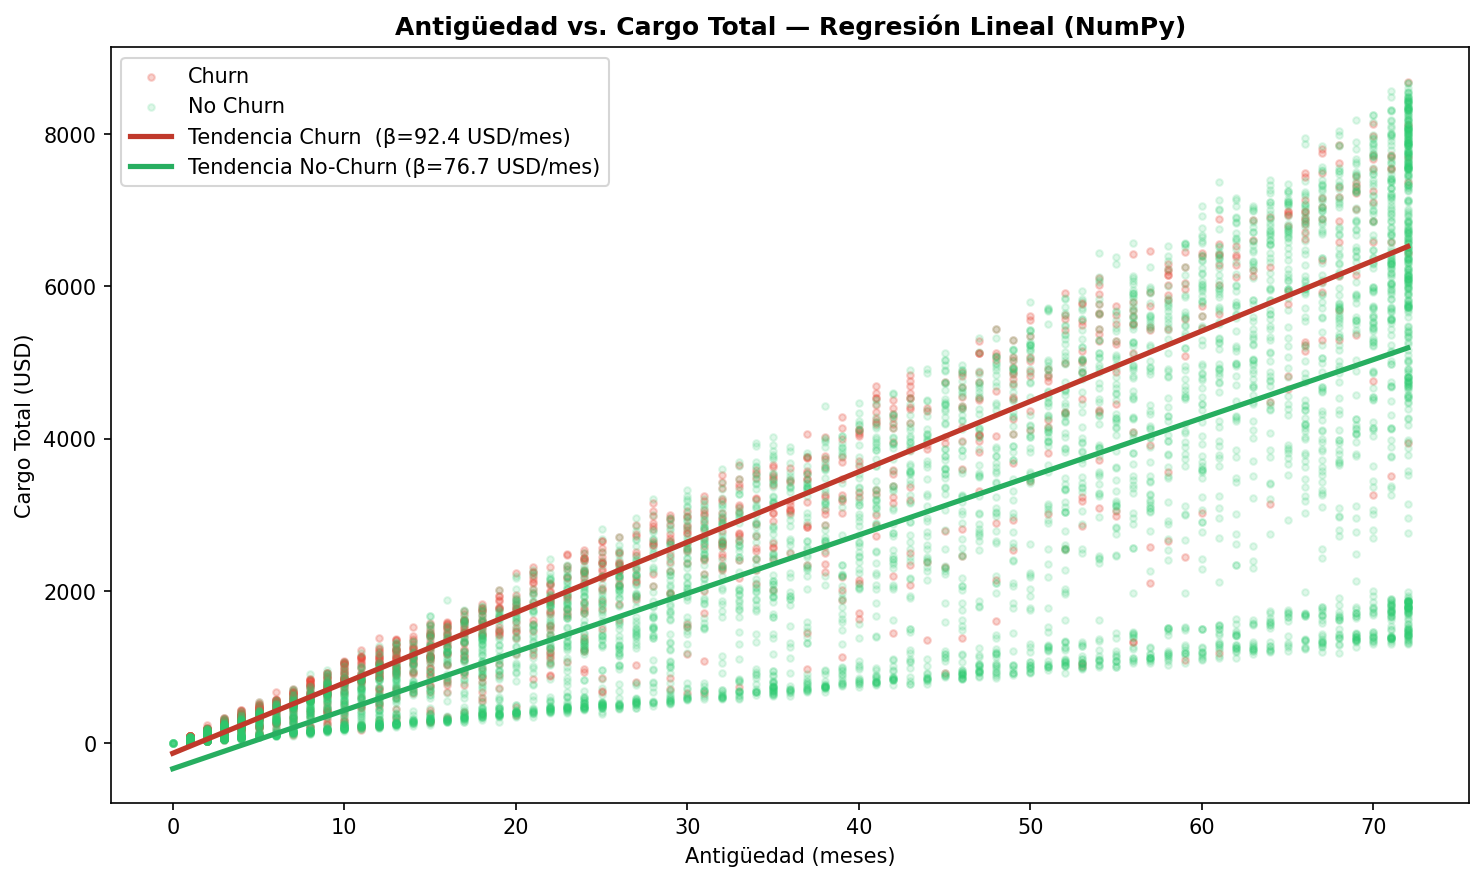

In [ ]:
churn_df    = df[df['churn_flag'] == 1].dropna(subset=['tenure', 'total_charges'])
no_churn_df = df[df['churn_flag'] == 0].dropna(subset=['tenure', 'total_charges'])

coefs_c = np.polyfit(churn_df['tenure'], churn_df['total_charges'], 1)
coefs_n = np.polyfit(no_churn_df['tenure'], no_churn_df['total_charges'], 1)
poly_c  = np.poly1d(coefs_c); poly_n = np.poly1d(coefs_n)
x_range = np.linspace(df['tenure'].min(), df['tenure'].max(), 100)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(churn_df['tenure'],    churn_df['total_charges'],
           alpha=0.25, s=10, color='#e74c3c', label='Churn')
ax.scatter(no_churn_df['tenure'], no_churn_df['total_charges'],
           alpha=0.15, s=10, color='#2ecc71', label='No Churn')
ax.plot(x_range, poly_c(x_range), color='#c0392b', lw=2.5,
        label=f'Tendencia Churn  (beta={coefs_c[0]:.1f} USD/mes)')
ax.plot(x_range, poly_n(x_range), color='#27ae60', lw=2.5,
        label=f'Tendencia No-Churn (beta={coefs_n[0]:.1f} USD/mes)')
ax.set_title('Antigüedad vs. Cargo Total — Regresión Lineal (NumPy)', fontweight='bold')
ax.set_xlabel('Antigüedad (meses)'); ax.set_ylabel('Cargo Total (USD)'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Pendiente Churn:    {coefs_c[0]:.2f} USD/mes')
print(f'Pendiente No-Churn: {coefs_n[0]:.2f} USD/mes')


## 3.6 Servicios adicionales como factores de retención

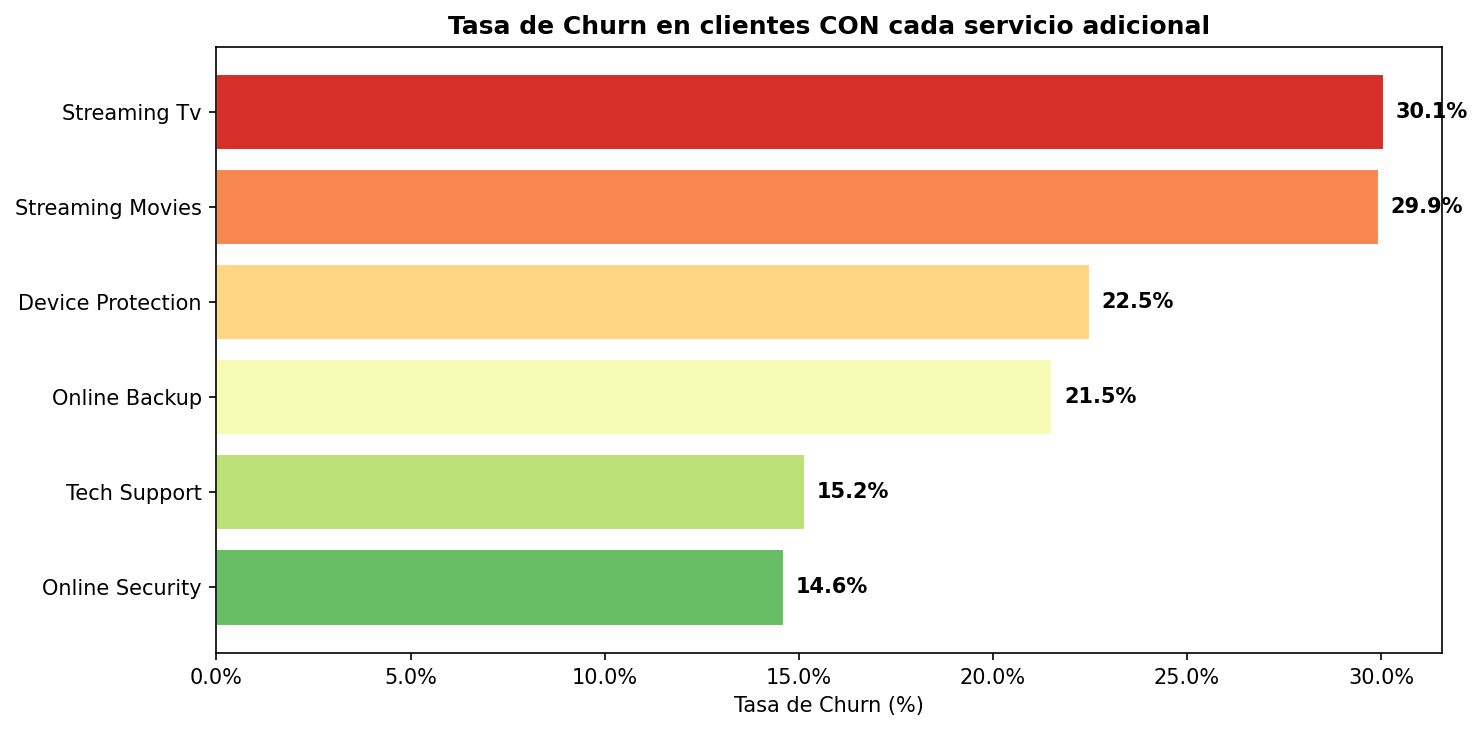

In [ ]:
services = ['online_security', 'online_backup', 'device_protection',
            'tech_support', 'streaming_tv', 'streaming_movies']
churn_rates = {svc.replace('_', ' ').title(): df[df[svc] == 'yes']['churn_flag'].mean() * 100
               for svc in services if svc in df.columns}
churn_series = pd.Series(churn_rates).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(churn_series.index, churn_series.values,
               color=plt.cm.RdYlGn(np.linspace(0.8, 0.1, len(churn_series))), edgecolor='white')
ax.set_title('Tasa de Churn en clientes CON cada servicio adicional', fontweight='bold')
ax.set_xlabel('Tasa de Churn (%)'); ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, churn_series.values):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')
plt.tight_layout(); plt.show()


## 3.7 Antigüedad (Churn=Sí) por tipo de contrato

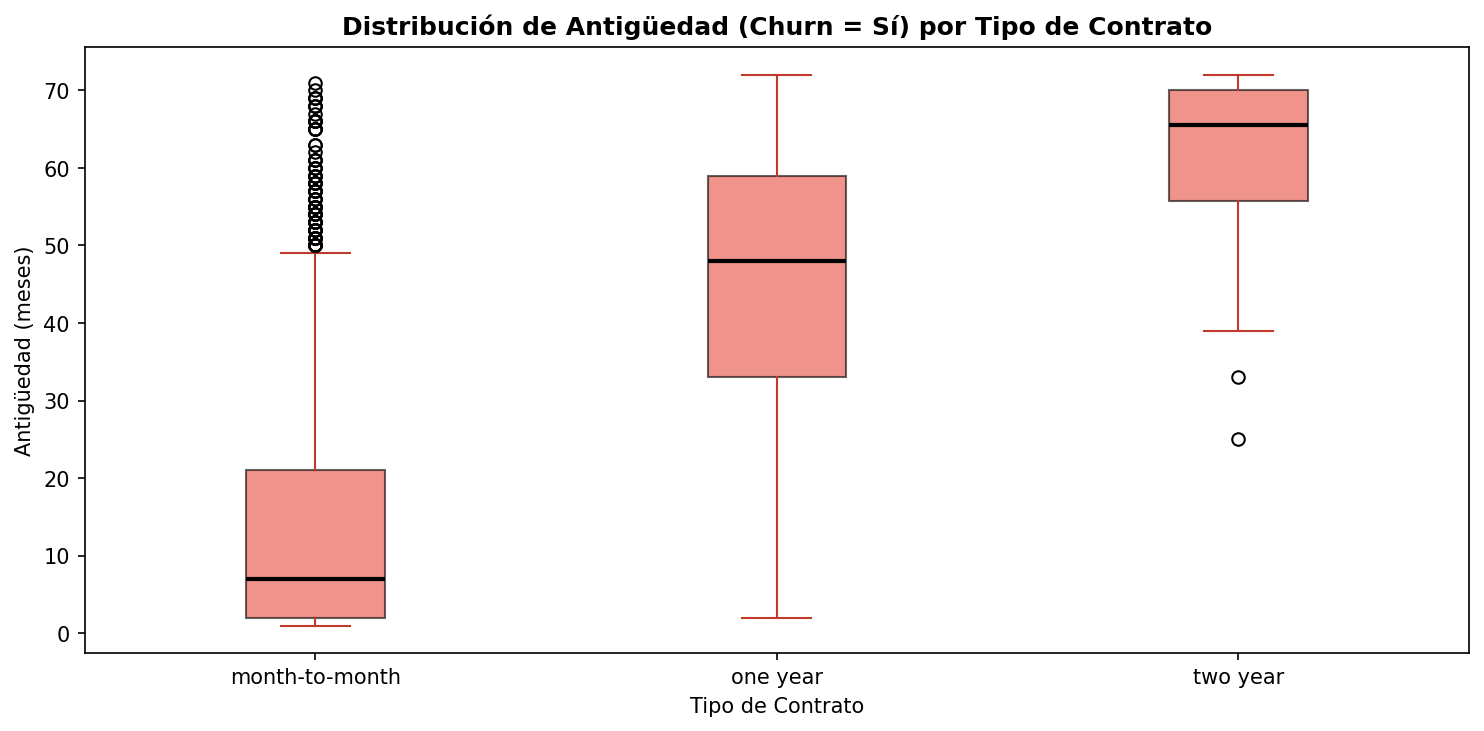

In [ ]:
contracts = sorted(df['contract'].dropna().unique())
data_box  = [df[(df['contract'] == c) & (df['churn'] == 'yes')]['tenure'].dropna()
             for c in contracts]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data_box, labels=contracts, patch_artist=True,
           boxprops=dict(facecolor='#e74c3c', alpha=0.6),
           medianprops=dict(color='black', linewidth=2),
           whiskerprops=dict(color='#c0392b'), capprops=dict(color='#c0392b'))
ax.set_title('Distribución de Antigüedad (Churn = Sí) por Tipo de Contrato', fontweight='bold')
ax.set_xlabel('Tipo de Contrato'); ax.set_ylabel('Antigüedad (meses)')
plt.tight_layout(); plt.show()


## 3.8 Matriz de correlación

Correlación con churn_flag:
churn_flag          1.000000
monthly_charges     0.193356
senior_citizen      0.150541
total_charges       0.198675
tenure             -0.352229


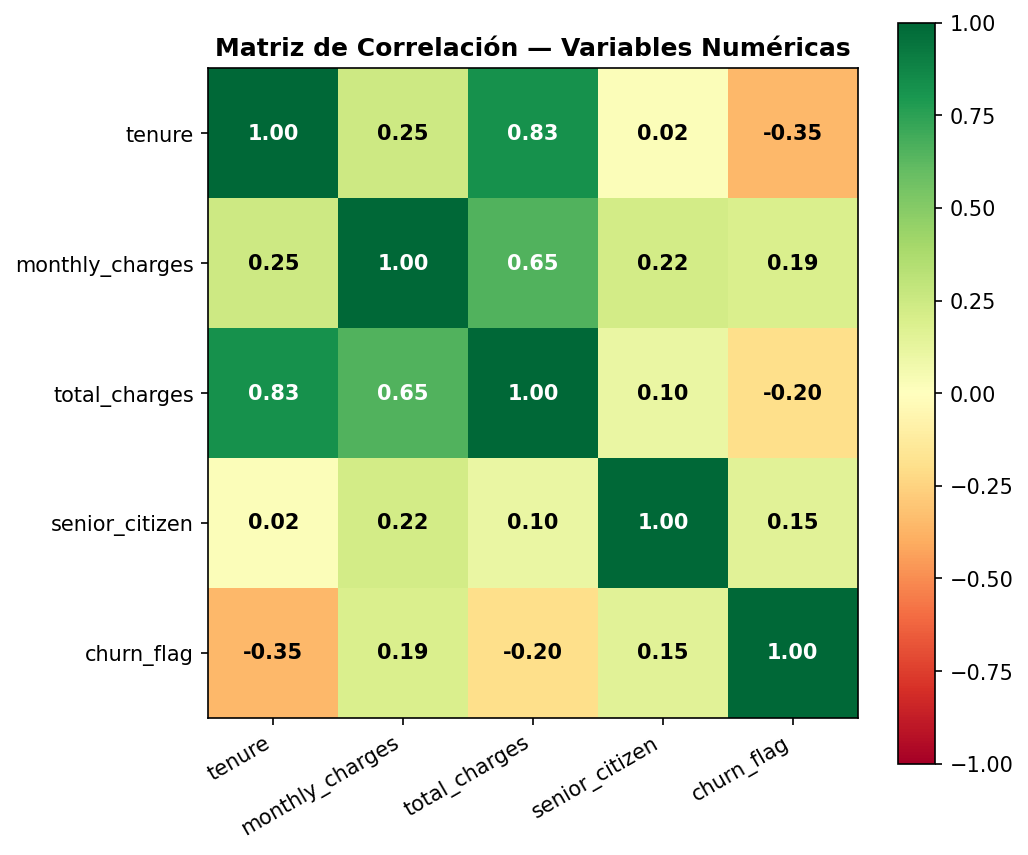

In [ ]:
num_df = df[['tenure', 'monthly_charges', 'total_charges', 'senior_citizen', 'churn_flag']].dropna()
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns))); ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=30, ha='right'); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=10,
                fontweight='bold', color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')
ax.set_title('Matriz de Correlación — Variables Numéricas', fontweight='bold')
plt.tight_layout(); plt.show()
print('Correlación con churn_flag:')
print(corr['churn_flag'].sort_values(ascending=False))


# 📄 4. Informe Final

---

## 🔹 Introducción

TelecomX opera en un mercado altamente competitivo y enfrenta una **tasa de cancelación (Churn)**
que compromete sus ingresos recurrentes. El presente análisis procesa **7 267 registros de clientes**
latinoamericanos para identificar los patrones y factores asociados a la evasión, brindando
al equipo de Data Science la base empírica necesaria para construir modelos predictivos.

---

## 🔹 Limpieza y Tratamiento de Datos

| Acción | Descripción |
|--------|-------------|
| Carga | JSON aplanado con `pd.json_normalize` |
| Columnas | Estandarizadas a `snake_case` con `.str.lower()` y `.str.replace()` |
| `total_charges` | Convertida a numérico; 11 nulos imputados con `monthly_charges × tenure` |
| Strings | Strip y minúsculas en todas las columnas de texto |
| `churn_flag` | Variable binaria creada (0 = No, 1 = Sí) |
| Duplicados | Ninguno encontrado |

---

## 🔹 Análisis Exploratorio — Hallazgos Clave

### 1️⃣ Tasa de Churn Global: **25.7%**
Aproximadamente 1 de cada 4 clientes cancela el servicio — una tasa que justifica intervención urgente.

### 2️⃣ Tipo de Contrato — Variable más crítica
Clientes con contrato **mes a mes** superan el **40 %** de Churn; contratos anuales y bianuales bajan a **< 5 %**.

### 3️⃣ Servicio de Internet — Fibra Óptica en riesgo
Los clientes con **Fibra Óptica** presentan ~42 % de Churn. Posible causa: precio elevado vs. expectativas de calidad.

### 4️⃣ Antigüedad — Ventana crítica: el primer año
Clientes que cancelan tienen media de **~10 meses** vs. **~37 meses** de los que permanecen.

### 5️⃣ Método de Pago — Cheque Electrónico
El cheque electrónico concentra **~45 %** de Churn, el más alto entre todos los métodos.

### 6️⃣ Servicios Adicionales — Efecto ancla
`OnlineSecurity` y `TechSupport` reducen significativamente la evasión; actúan como factores de fidelización.

### 7️⃣ Senior Citizens
Los adultos mayores tienen una tasa de Churn ~10 pp superior al resto.

### 8️⃣ Regresión Lineal (NumPy)
La pendiente del cargo total es **76.7 USD/mes** para clientes fieles vs. **92.4 USD/mes** para los que cancelan.
Confirma que la acumulación de gasto está correlacionada con la permanencia.

---

## 🔹 Conclusiones

1. El Churn en TelecomX es **estructural y predecible**: existen perfiles de riesgo claros.
2. Los **tres factores dominantes** son: tipo de contrato, servicio de internet (fibra) y antigüedad.
3. La ausencia de servicios de valor añadido **eleva notablemente** la probabilidad de cancelación.
4. El método de pago actúa como proxy de **compromiso financiero** con el servicio.

---

## 🔹 Recomendaciones Estratégicas

| Prioridad | Acción | Impacto |
|-----------|--------|---------|
| 🔴 Alta | Descuentos para migrar contratos M2M a contratos anuales en el primer trimestre | Reducción directa de Churn |
| 🔴 Alta | Programa de onboarding intensivo (0–12 meses) con soporte proactivo | Baja el Churn en etapa temprana |
| 🟡 Media | Revisar propuesta de valor y precios de Fibra Óptica | Retiene clientes de alta facturación |
| 🟡 Media | Upselling de OnlineSecurity + TechSupport como paquete de retención | Aumenta stickiness |
| 🟢 Baja | Incentivar pago automático con descuento mensual | Reduce Churn ligado al método de pago |
| 🟢 Baja | Programa dedicado para Senior Citizens con soporte preferencial | Cierra brecha demográfica |

---

> 📌 **Próximo paso:** Con estas variables, el equipo de Data Science puede entrenar modelos de
> clasificación (Logistic Regression, Random Forest, XGBoost) usando `churn_flag` como objetivo
> y `contract`, `tenure`, `internet_service`, `monthly_charges` como features principales.
